In [11]:
import pandas as pd

df = pd.read_csv("results/scalabilityExperimentMSDv3.csv")
# df = pd.read_csv("partial/scalabilityExperimentcVaR_partial.csv")

In [12]:
display(df)
plot_df = df.copy()

plot_df["method_small"] = "small_support"
plot_df["method_mcp"] = "path_MCP"
plot_df["problem_size"] = plot_df["K"] * plot_df["n"] * plot_df["n"]

summary = plot_df.groupby(["K", "n", "kappa", "tau"], as_index=False, dropna=False).agg(
    reps=("seed", "count"),
    problem_size=("problem_size", "first"),
    small_success_rate=("small_success", "mean"),
    mcp_success_rate=("mcp_success", "mean"),
    small_time_median=("small_time_s", "median"),
    mcp_time_median=("mcp_time_s", "median"),
    small_time_q25=("small_time_s", lambda x: x.quantile(0.25)),
    small_time_q75=("small_time_s", lambda x: x.quantile(0.75)),
    mcp_time_q25=("mcp_time_s", lambda x: x.quantile(0.25)),
    mcp_time_q75=("mcp_time_s", lambda x: x.quantile(0.75)),
    small_eta_median=("small_eta", "median"),
    mcp_eta_median=("mcp_eta", "median"),
)

small_summary = (
    plot_df[plot_df["small_success"]]
    .groupby(["K", "n", "kappa", "tau"], as_index=False)
    .agg(
        reps_succ_small=("seed", "count"),
        problem_size=("problem_size", "first"),
        small_time_median=("small_time_s", "median"),
        small_time_q25=("small_time_s", lambda x: x.quantile(0.25)),
        small_time_q75=("small_time_s", lambda x: x.quantile(0.75)),
        small_eta_median=("small_eta", "median"),
    )
)

mcp_summary = (
    plot_df[plot_df["mcp_success"]]
    .groupby(["K", "n", "kappa", "tau"], as_index=False)
    .agg(
        reps_succ_mcp=("seed", "count"),
        problem_size=("problem_size", "first"),
        mcp_time_median=("mcp_time_s", "median"),
        mcp_time_q25=("mcp_time_s", lambda x: x.quantile(0.25)),
        mcp_time_q75=("mcp_time_s", lambda x: x.quantile(0.75)),
        mcp_eta_median=("mcp_eta", "median"),
    )
)

success_summary = mcp_summary.merge(
    small_summary, on=["K", "n", "kappa", "tau", "problem_size"], how="outer"
)
display(success_summary)
display(summary)

,K,n,seed,gamma,eps,kappa,tau,small_time_s,small_success,small_eta,small_screen_eta,small_support_eta,small_has_profile,mcp_time_s,mcp_success,mcp_eta
0,5,5,50623,0.5,0.01,3,5,16.242574,True,0.000000e+00,-0.177122,0.000000e+00,True,0.053289,True,0.000000e+00
1,5,5,50624,0.5,0.01,3,5,22.643502,True,3.578556e-07,-0.068145,3.578556e-07,True,0.081747,True,1.110223e-16
2,5,5,50625,0.5,0.01,3,5,63.643251,True,3.877530e-03,-0.157717,3.877530e-03,True,0.088332,True,5.551115e-17
3,5,5,50626,0.5,0.01,3,5,9.508443,True,0.000000e+00,-0.087512,0.000000e+00,True,0.077569,True,0.000000e+00
4,5,5,50627,0.5,0.01,3,5,18.277515,True,8.352888e-03,-0.120041,8.352888e-03,True,0.063206,True,1.110223e-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,500,50,5005138,0.5,0.01,8,23,3519.182844,True,5.568982e-03,0.003340,5.568982e-03,True,289.853521,False,NaN
476,500,50,5005139,0.5,0.01,8,23,3259.600434,True,6.081942e-03,0.005733,6.081942e-03,True,333.670160,False,NaN
477,500,50,5005140,0.5,0.01,8,23,1605.129615,True,4.600667e-03,0.006161,4.600667e-03,True,349.627972,False,NaN
478,500,50,5005141,0.5,0.01,8,23,2347.878967,True,6.155607e-03,0.004421,6.155607e-03,True,252.669258,False,NaN


,K,n,kappa,tau,reps_succ_mcp,problem_size,mcp_time_median,mcp_time_q25,mcp_time_q75,mcp_eta_median,reps_succ_small,small_time_median,small_time_q25,small_time_q75,small_eta_median
0,5,5,3,5,20.0,125,0.058466,0.054106,0.069785,2.775558e-17,20,31.952590,17.768780,48.962534,0.000172
1,5,10,4,5,18.0,500,0.085665,0.080251,0.089088,0.000000e+00,20,83.195537,34.675117,154.150774,0.000513
2,5,20,5,5,17.0,2000,0.240167,0.211747,0.284003,1.110223e-16,20,174.713369,131.583771,292.309609,0.005279
3,5,50,8,5,11.0,12500,1.085620,0.909624,1.149304,0.000000e+00,20,1150.821820,601.517390,2487.809981,0.004510
4,10,5,3,5,20.0,250,0.092922,0.090279,0.103537,0.000000e+00,20,28.265577,24.386332,54.544887,0.000071
5,10,10,4,5,19.0,1000,0.150871,0.142476,0.176112,1.110223e-16,20,92.184298,40.594631,118.216785,0.006297
6,10,20,5,5,17.0,4000,0.424320,0.391762,0.459032,1.110223e-16,20,186.729932,59.302217,336.363580,0.005964
7,10,50,8,5,9.0,25000,2.117279,2.051798,2.146455,1.110223e-16,20,405.309317,188.448329,892.932664,0.006150
8,30,5,3,6,20.0,750,0.168320,0.162009,0.226096,2.886580e-15,20,45.779719,30.641164,56.284607,0.002736
9,30,10,4,6,16.0,3000,0.368998,0.328192,0.387875,1.110223e-16,20,80.128031,46.222567,135.325962,0.004347


,K,n,kappa,tau,reps,problem_size,small_success_rate,mcp_success_rate,small_time_median,mcp_time_median,small_time_q25,small_time_q75,mcp_time_q25,mcp_time_q75,small_eta_median,mcp_eta_median
0,5,5,3,5,20,125,1.00,1.00,31.952590,0.058466,17.768780,48.962534,0.054106,0.069785,0.000172,2.775558e-17
1,5,10,4,5,20,500,1.00,0.90,83.195537,0.086073,34.675117,154.150774,0.080459,0.090177,0.000513,0.000000e+00
2,5,20,5,5,20,2000,1.00,0.85,174.713369,0.257238,131.583771,292.309609,0.213621,0.309703,0.005279,1.110223e-16
3,5,50,8,5,20,12500,1.00,0.55,1150.821820,1.168055,601.517390,2487.809981,1.070083,1.933638,0.004510,0.000000e+00
4,10,5,3,5,20,250,1.00,1.00,28.265577,0.092922,24.386332,54.544887,0.090279,0.103537,0.000071,0.000000e+00
5,10,10,4,5,20,1000,1.00,0.95,92.184298,0.158542,40.594631,118.216785,0.143405,0.175812,0.006297,1.110223e-16
6,10,20,5,5,20,4000,1.00,0.85,186.729932,0.437363,59.302217,336.363580,0.403154,0.528931,0.005964,1.110223e-16
7,10,50,8,5,20,25000,1.00,0.45,405.309317,2.196359,188.448329,892.932664,2.061484,3.245265,0.006150,1.110223e-16
8,30,5,3,6,20,750,1.00,1.00,45.779719,0.168320,30.641164,56.284607,0.162009,0.226096,0.002736,2.886580e-15
9,30,10,4,6,20,3000,1.00,0.80,80.128031,0.373143,46.222567,135.325962,0.340013,0.463076,0.004347,1.110223e-16


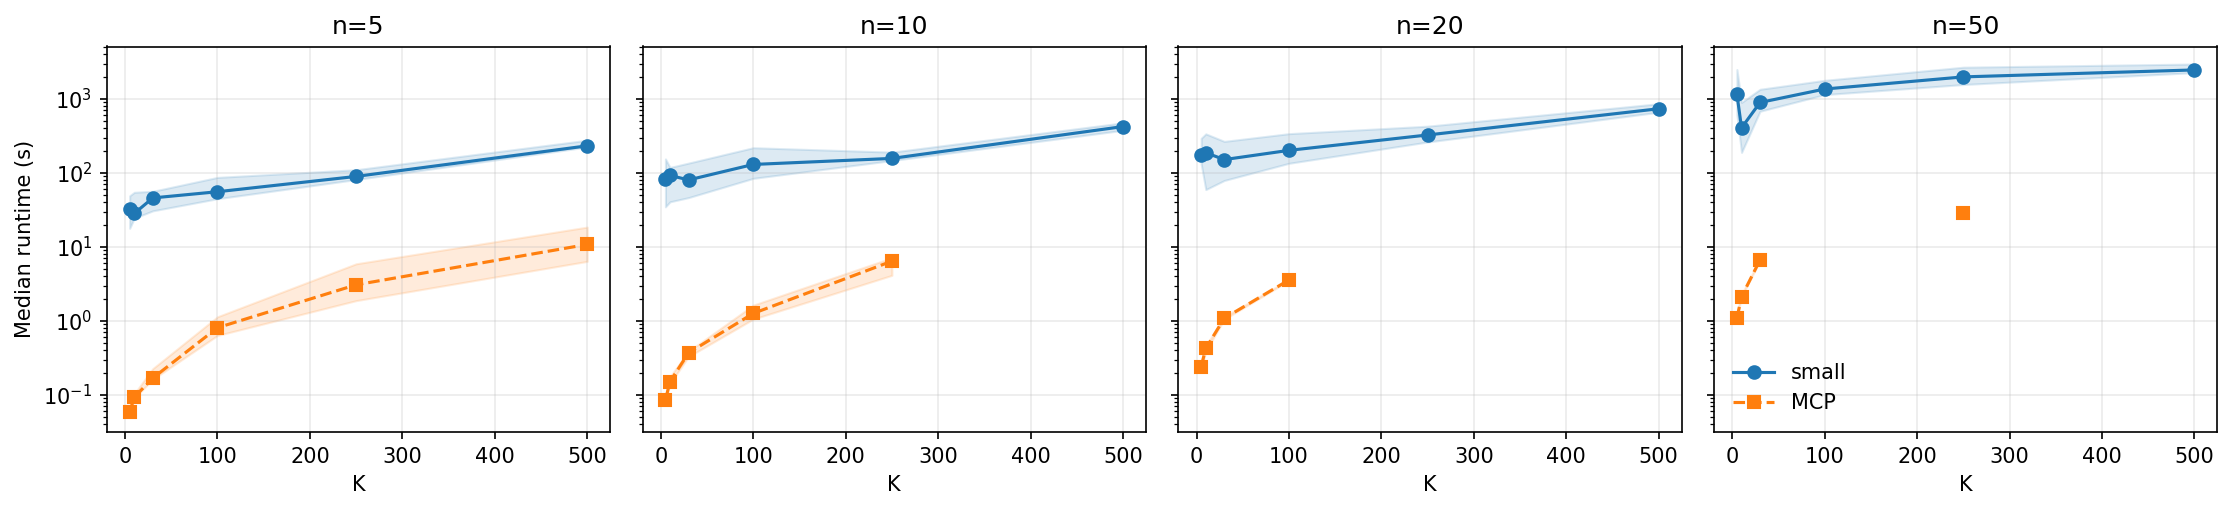

In [13]:
import matplotlib.pyplot as plt

K_grid = [5, 10, 30, 100, 250, 500]
n_grid = [5, 10, 20, 50]

small_color = "tab:blue"
mcp_color = "tab:orange"
fig, axes = plt.subplots(1, len(n_grid), figsize=(15, 3.5), dpi=150, sharey=True)

for ax, n in zip(axes, n_grid):
    s = success_summary[success_summary["n"] == n].sort_values("K")

    ax.plot(s["K"], s["small_time_median"], "o-", label="small", color=small_color)
    ax.fill_between(
        s["K"],
        s["small_time_q25"],
        s["small_time_q75"],
        color=small_color,
        alpha=0.15,
        label="_nolegend_",
    )

    ax.plot(s["K"], s["mcp_time_median"], "s--", label="MCP", color=mcp_color)
    ax.fill_between(
        s["K"],
        s["mcp_time_q25"],
        s["mcp_time_q75"],
        color=mcp_color,
        alpha=0.15,
        label="_nolegend_",
    )

    ax.set_yscale("log")
    ax.set_title(f"n={n}")
    ax.set_xlabel("K")
    ax.grid(alpha=0.25)

axes[0].set_ylabel("Median runtime (s)")
axes[-1].legend(frameon=False)
plt.tight_layout()
plt.show()

# remove header
# add no successful runs and legend
# describe the setup for the experiment and the hardware

In [15]:
import matplotlib.pyplot as plt

K_grid = [5, 10, 30, 100, 250, 500]
n_grid = [5, 10, 20, 50]

cmap = plt.get_cmap("inferno")
small_color = cmap(0.25)
mcp_color = cmap(0.75)

fig, axes = plt.subplots(
    1,
    len(n_grid),
    figsize=(15, 3.5),
    dpi=150,
    sharey=True,
)

for ax, n in zip(axes, n_grid):
    s = summary[summary["n"] == n].sort_values("K")

    small_zero = s["small_success_rate"] == 0
    mcp_zero = s["mcp_success_rate"] == 0

    # Lines only, no markers
    ax.plot(
        s["K"],
        s["small_time_median"],
        "-",
        color=small_color,
        linewidth=1.8,
        label="small-support" if n == n_grid[0] else "_nolegend_",
    )
    ax.plot(
        s["K"],
        s["mcp_time_median"],
        "--",
        color=mcp_color,
        linewidth=1.8,
        label="MCP" if n == n_grid[0] else "_nolegend_",
    )

    # IQR bands
    ax.fill_between(
        s["K"],
        s["small_time_q25"],
        s["small_time_q75"],
        color=small_color,
        alpha=0.15,
    )
    ax.fill_between(
        s["K"],
        s["mcp_time_q25"],
        s["mcp_time_q75"],
        color=mcp_color,
        alpha=0.15,
    )

    # Normal markers only where success rate > 0
    ax.scatter(
        s.loc[~small_zero, "K"],
        s.loc[~small_zero, "small_time_median"],
        marker="o",
        s=28,
        color=small_color,
        zorder=4,
    )
    ax.scatter(
        s.loc[~mcp_zero, "K"],
        s.loc[~mcp_zero, "mcp_time_median"],
        marker="s",
        s=28,
        color=mcp_color,
        zorder=4,
    )

    # Cross markers only where success rate == 0
    ax.scatter(
        s.loc[small_zero, "K"],
        s.loc[small_zero, "small_time_median"],
        marker="x",
        s=70,
        linewidths=2.0,
        color=small_color,
        label="small-support: failed" if n == n_grid[0] else "_nolegend_",
        zorder=5,
    )
    ax.scatter(
        s.loc[mcp_zero, "K"],
        s.loc[mcp_zero, "mcp_time_median"],
        marker="x",
        s=70,
        linewidths=2.0,
        color=mcp_color,
        label="MCP: failed" if n == n_grid[0] else "_nolegend_",
        zorder=5,
    )

    ax.set_yscale("log")
    ax.set_title(f"n={n}", fontsize=15)
    ax.set_xlabel("K", fontsize=15)
    ax.tick_params(labelsize=15)
    ax.grid(alpha=0.25)
    ax.set_xticks(range(100, 501, 100))

axes[0].set_ylabel("Median runtime (s)", fontsize=15)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, -0.08),
    fontsize=15,
)
fig.set_dpi(1200)
plt.tight_layout()
plt.show()

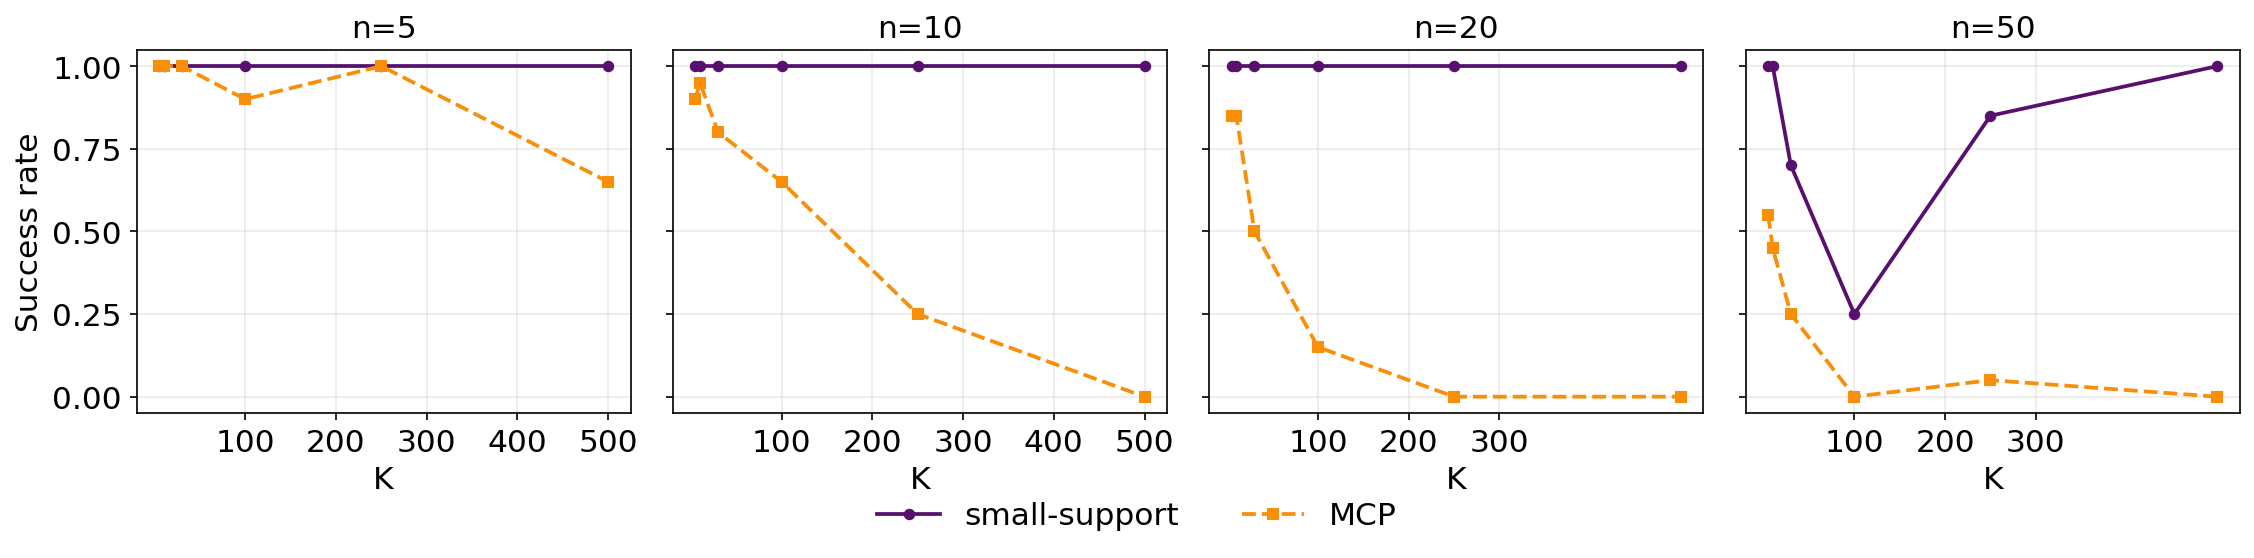

In [16]:
import matplotlib.pyplot as plt

K_grid = [5, 10, 30, 100, 250, 500]
n_grid = [5, 10, 20, 50]

cmap = plt.get_cmap("inferno")
small_color = cmap(0.25)
mcp_color = cmap(0.75)

fig, axes = plt.subplots(
    1,
    len(n_grid),
    figsize=(15, 3.5),
    dpi=150,
    sharey=True,
)

for ax, n in zip(axes, n_grid):
    s = summary[summary["n"] == n].sort_values("K")

    ax.plot(
        s["K"],
        s["small_success_rate"],
        "o-",
        label="small-support" if n == n_grid[0] else "_nolegend_",
        color=small_color,
        linewidth=1.8,
        markersize=4.5,
    )

    ax.plot(
        s["K"],
        s["mcp_success_rate"],
        "s--",
        label="MCP" if n == n_grid[0] else "_nolegend_",
        color=mcp_color,
        linewidth=1.8,
        markersize=4.5,
    )

    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f"n={n}", fontsize=15)
    ax.set_xlabel("K", fontsize=15)
    ax.grid(alpha=0.25)
    if n not in [20, 50]:
        ax.set_xticks(range(100, 501, 100))
    else:
        ax.set_xticks(range(100, 301, 100))
    ax.tick_params(labelsize=15)

axes[0].set_ylabel("Success rate", fontsize=15)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.08),
    fontsize=15,
)

plt.tight_layout()
plt.show()

In [6]:
display_cols = [
    "K",
    "n",
    "kappa",
    "tau",
    "reps",
    "problem_size",
    "small_success_rate",
    "mcp_success_rate",
    "small_time_median",
    "mcp_time_median",
    "small_eta_median",
    "mcp_eta_median",
]

summary[display_cols].sort_values(["K", "n"])

,K,n,kappa,tau,reps,problem_size,small_success_rate,mcp_success_rate,small_time_median,mcp_time_median,small_eta_median,mcp_eta_median
0,5,5,3,5,20,125,1.00,1.00,31.952590,0.058466,0.000172,2.775558e-17
1,5,10,4,5,20,500,1.00,0.90,83.195537,0.086073,0.000513,0.000000e+00
2,5,20,5,5,20,2000,1.00,0.85,174.713369,0.257238,0.005279,1.110223e-16
3,5,50,8,5,20,12500,1.00,0.55,1150.821820,1.168055,0.004510,0.000000e+00
4,10,5,3,5,20,250,1.00,1.00,28.265577,0.092922,0.000071,0.000000e+00
5,10,10,4,5,20,1000,1.00,0.95,92.184298,0.158542,0.006297,1.110223e-16
6,10,20,5,5,20,4000,1.00,0.85,186.729932,0.437363,0.005964,1.110223e-16
7,10,50,8,5,20,25000,1.00,0.45,405.309317,2.196359,0.006150,1.110223e-16
8,30,5,3,6,20,750,1.00,1.00,45.779719,0.168320,0.002736,2.886580e-15
9,30,10,4,6,20,3000,1.00,0.80,80.128031,0.373143,0.004347,1.110223e-16
